<a href="https://colab.research.google.com/github/agent182000/stockmarketprediction/blob/main/timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
import logging
from datetime import datetime, timedelta

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class NSEDataLoader:
    def __init__(self, tickers: list, years: int = 10, output_dir: str = "/content/drive/MyDrive/nse_research_data"):
        self.tickers = tickers
        self.end_date = datetime.today()
        self.start_date = self.end_date - timedelta(days=years * 365)
        self.output_dir = output_dir

        os.makedirs(self.output_dir, exist_ok=True)

    def _calculate_rsi(self, data: pd.Series, window: int = 14) -> pd.Series:
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    def _calculate_macd(self, data: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9) -> pd.DataFrame:
        exp1 = data.ewm(span=fast, adjust=False).mean()
        exp2 = data.ewm(span=slow, adjust=False).mean()
        macd = exp1 - exp2
        signal_line = macd.ewm(span=signal, adjust=False).mean()
        return macd, signal_line

    def fetch_and_process(self):
        all_data = []
        for ticker in self.tickers:
            logging.info(f"Fetching data for {ticker}...")
            try:
                df = yf.download(ticker, start=self.start_date.strftime('%Y-%m-%d'),
                                 end=self.end_date.strftime('%Y-%m-%d'), progress=False)

                if df.empty:
                    continue

                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.droplevel(1)

                df['Ticker'] = ticker
                df['RSI_14'] = self._calculate_rsi(df['Close'])
                df['MACD'], df['MACD_Signal'] = self._calculate_macd(df['Close'])

                df = df.dropna()
                all_data.append(df)
                logging.info(f"Processed {ticker}. Shape: {df.shape}")

            except Exception as e:
                logging.error(f"Failed {ticker}: {e}")

        if all_data:
            final_df = pd.concat(all_data)
            output_path = os.path.join(self.output_dir, "nse_10yr_processed.parquet")
            final_df.to_parquet(output_path, engine='pyarrow')
            logging.info(f"Saved to {output_path}")
            return final_df
        return None

# Target Tickers (Nifty 50)
target_tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS']
loader = NSEDataLoader(tickers=target_tickers, years=10)
processed_data = loader.fetch_and_process()

/tmp/ipykernel_2500/2861641308.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date.strftime('%Y-%m-%d'),
/tmp/ipykernel_2500/2861641308.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date.strftime('%Y-%m-%d'),
/tmp/ipykernel_2500/2861641308.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date.strftime('%Y-%m-%d'),
/tmp/ipykernel_2500/2861641308.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date.strftime('%Y-%m-%d'),
/tmp/ipykernel_2500/2861641308.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date.strftime('%Y-%m-%d'),


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

class NSETimeSeriesDataset(Dataset):
    """
    Slices the stock data into overlapping windows (e.g., 30 days of history -> 1 day forecast).
    """
    def __init__(self, data, seq_length=30):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, index):
        # The 'X' is the sequence of past days
        x = self.data[index:(index + self.seq_length)]
        # The 'Y' is the target value we want to predict (e.g., the Close price of the next day)
        y = self.data[index + self.seq_length, 3] # Assuming index 3 is the 'Close' price

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

def prepare_dataloaders(parquet_path, target_ticker='RELIANCE.NS', seq_length=30, batch_size=64):
    """Loads data, scales it, and returns PyTorch dataloaders."""

    # 1. Load the data
    df = pd.read_parquet(parquet_path)

    # Filter for just one stock to start our baseline
    df_ticker = df[df['Ticker'] == target_ticker].copy()

    # Drop the Ticker column and keep only numerical features (Open, High, Low, Close, Volume, RSI, MACD)
    features = ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI_14', 'MACD', 'MACD_Signal']
    data_values = df_ticker[features].values

    # 2. Scale the data (LSTMs hate large numbers, we must scale to 0-1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data_values)

    # 3. Train/Test Split (80% train, 20% test chronologically)
    train_size = int(len(scaled_data) * 0.8)
    train_data = scaled_data[:train_size]
    test_data = scaled_data[train_size:]

    # 4. Create Datasets
    train_dataset = NSETimeSeriesDataset(train_data, seq_length)
    test_dataset = NSETimeSeriesDataset(test_data, seq_length)

    # 5. Create DataLoaders (this batches the data and feeds it to the GPU)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Dataset for {target_ticker} prepped!")
    print(f"Training sequences: {len(train_dataset)} | Testing sequences: {len(test_dataset)}")

    return train_loader, test_loader, scaler

# Execute the prep
# Make sure this path matches where you saved it in your Google Drive
parquet_file_path = "/content/drive/MyDrive/nse_research_data/nse_10yr_processed.parquet"

train_loader, test_loader, price_scaler = prepare_dataloaders(
    parquet_path=parquet_file_path,
    target_ticker='RELIANCE.NS', # We will train the baseline on Reliance
    seq_length=30,               # Look back 30 trading days
    batch_size=64                # Process 64 windows at a time
)

Dataset for RELIANCE.NS prepped!
Training sequences: 1933 | Testing sequences: 461


In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Define the Neural Network Architecture
class BaselineLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, output_size=1):
        super(BaselineLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # The LSTM layer
        # batch_first=True means inputs are shape (batch_size, sequence_length, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)

        # The fully connected output layer (predicts the single next price)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden and cell states (the "memory" of the network)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward pass through the LSTM
        out, _ = self.lstm(x, (h0, c0))

        # We only want the output from the very last time step in the sequence
        out = self.fc(out[:, -1, :])
        return out

# 2. Setup the Training Environment
# Use GPU if Colab has one assigned to you, otherwise fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

# Initialize the model, move it to the GPU
model = BaselineLSTM(input_size=8).to(device)

# Mean Squared Error (Standard for point forecasting)
criterion = nn.MSELoss()

# Adam optimizer (standard for time-series)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. The Training Loop
epochs = 50

print("Starting training...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    # Loop through batches of 64 sequences
    for batch_x, batch_y in train_loader:
        # Move data to GPU
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # Zero the gradients (clear old memory from the last step)
        optimizer.zero_grad()

        # Forward pass: make a prediction
        outputs = model(batch_x)

        # Calculate how wrong the prediction was
        loss = criterion(outputs.squeeze(), batch_y)

        # Backward pass: calculate the updates
        loss.backward()

        # Update the weights
        optimizer.step()

        train_loss += loss.item()

    # Calculate average loss for the epoch
    avg_train_loss = train_loss / len(train_loader)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_train_loss:.6f}')

print("Training complete! Model weights are updated.")

Training on device: cuda
Starting training...
Epoch [10/50], Loss: 0.006710
Epoch [20/50], Loss: 0.001528
Epoch [30/50], Loss: 0.001606
Epoch [40/50], Loss: 0.001858
Epoch [50/50], Loss: 0.001540
Training complete! Model weights are updated.


Test RMSE: ₹30.21 (Average error in Rupees)
Test MAPE: 1.77% (Average percentage error)


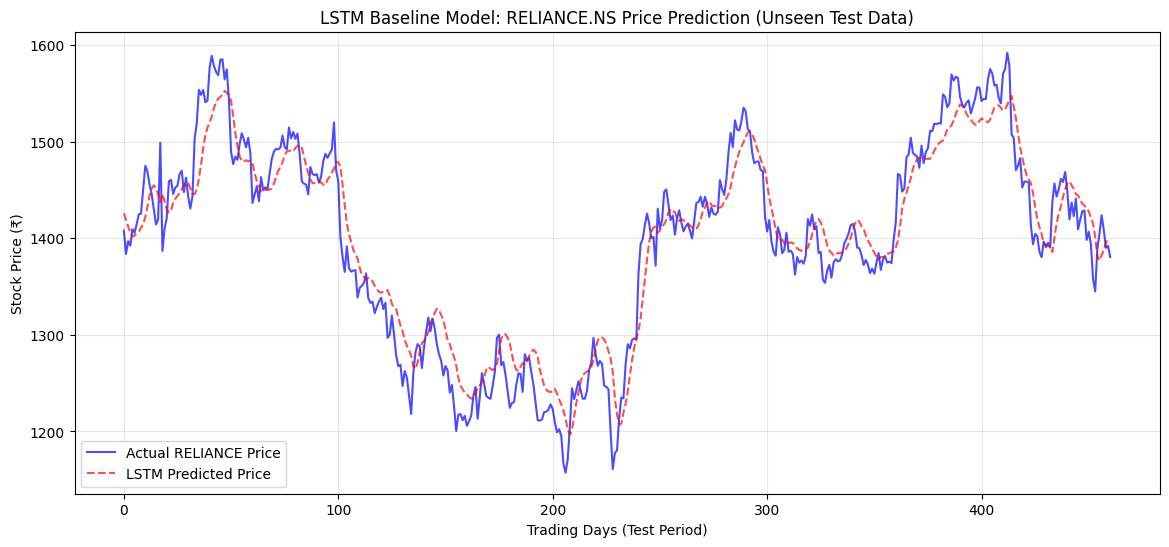

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Switch model to evaluation mode (turns off dropout layers)
model.eval()

predictions = []
actuals = []

# Turn off gradient tracking to save memory and speed up inference
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        # Move inputs to the same device as the model (CPU or GPU)
        batch_x = batch_x.to(device)

        # Get predictions
        outputs = model(batch_x)

        # Store predictions and actuals
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(batch_y.numpy())

# Flatten the lists into 1D numpy arrays
predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

# 2. Inverse Transform (The Tricky Part)
# Our scaler was originally fitted on 8 features, but we only predicted 1 (Close Price).
# We must create a "dummy" array of zeros, put our predictions in the 'Close' column (index 3),
# and then run the inverse transform to get real Rupee values.
def inverse_scale_target(data_array, scaler, target_col_idx=3, total_cols=8):
    dummy_array = np.zeros((len(data_array), total_cols))
    dummy_array[:, target_col_idx] = data_array
    return scaler.inverse_transform(dummy_array)[:, target_col_idx]

real_predictions = inverse_scale_target(predictions, price_scaler)
real_actuals = inverse_scale_target(actuals, price_scaler)

# 3. Calculate Academic Metrics for your paper
rmse = np.sqrt(mean_squared_error(real_actuals, real_predictions))
mape = mean_absolute_percentage_error(real_actuals, real_predictions) * 100

print(f"Test RMSE: ₹{rmse:.2f} (Average error in Rupees)")
print(f"Test MAPE: {mape:.2f}% (Average percentage error)")

# 4. Plotting the Results
plt.figure(figsize=(14, 6))
plt.plot(real_actuals, label='Actual RELIANCE Price', color='blue', alpha=0.7)
plt.plot(real_predictions, label='LSTM Predicted Price', color='red', alpha=0.7, linestyle='--')

plt.title('LSTM Baseline Model: RELIANCE.NS Price Prediction (Unseen Test Data)')
plt.xlabel('Trading Days (Test Period)')
plt.ylabel('Stock Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
!pip install pytorch-forecasting pytorch-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.8/399.8 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

# 1. Load your existing Parquet data
parquet_path = "/content/drive/MyDrive/nse_research_data/nse_10yr_processed.parquet"
df = pd.read_parquet(parquet_path)

# Filter for Reliance and reset index
df = df[df['Ticker'] == 'RELIANCE.NS'].copy()
df = df.reset_index(drop=True)

# 2. TFT requires an integer 'time_idx' to track sequence order
df['time_idx'] = np.arange(len(df))

# 3. Add some basic temporal features (TFT loves these)
# Assuming your original index was a DatetimeIndex from yfinance. If not, we can adjust.
if isinstance(df.index, pd.DatetimeIndex):
    df['day_of_week'] = df.index.dayofweek.astype(str).astype("category")
    df['month'] = df.index.month.astype(str).astype("category")
else:
    # Fallback if the date was lost in the parquet save
    df['day_of_week'] = "0"
    df['day_of_week'] = df['day_of_week'].astype("category")

# Ensure target is a float
df['Close'] = df['Close'].astype(float)

# 4. Define the TimeSeriesDataSet
# This is where we tell the model EXACTLY what every column means
max_prediction_length = 1  # Predict 1 day ahead
max_encoder_length = 30    # Look back 30 days (same as our LSTM)

# Split data: train on everything except the last 400 days
training_cutoff = df["time_idx"].max() - 400

training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Close",
    group_ids=["Ticker"], # Allows you to train on multiple stocks later!
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,

    # Static features (don't change over time)
    static_categoricals=["Ticker"],

    # Known future inputs (we know tomorrow's day of the week)
    time_varying_known_categoricals=["day_of_week"] if 'day_of_week' in df.columns and len(df['day_of_week'].unique()) > 1 else [],
    time_varying_known_reals=["time_idx"],

    # Unknown historical inputs (we don't know tomorrow's Volume or RSI)
    time_varying_unknown_reals=[
        "Open", "High", "Low", "Close", "Volume", "RSI_14", "MACD", "MACD_Signal"
    ],

    # TFT normalizes groups automatically! We don't need sklearn MinMaxScaler here.
    target_normalizer=GroupNormalizer(
        groups=["Ticker"], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# 5. Create PyTorch DataLoaders
validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

print(f"TFT Training sequences prepared: {len(training)}")

TFT Training sequences prepared: 2024


In [ ]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import TemporalFusionTransformer, QuantileLoss

# 1. Define the Model Architecture
# We pass the parameters directly from our training dataset so the model knows exactly
# how many features it has and what types they are.
tft = TemporalFusionTransformer.from_dataset(
    training,
    # Architecture size
    learning_rate=0.03,
    hidden_size=16,          # TFT doesn't need huge hidden sizes to be effective
    attention_head_size=1,   # Number of attention heads
    dropout=0.1,             # Prevent overfitting
    hidden_continuous_size=8,

    # This is the magic for Probabilistic Forecasting:
    # It will predict the 10th, 50th (median), and 90th percentiles.
    loss=QuantileLoss([0.1, 0.5, 0.9]),
    optimizer="Adam",      # Changed from "Ranger" to "Adam"
    reduce_on_plateau_patience=4,
)

print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

# 2. Configure the PyTorch Lightning Trainer
# Early stopping ensures we don't overfit. It stops training if the validation loss stops improving.
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
lr_logger = LearningRateMonitor()

trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",      # Automatically uses Colab's GPU if available, otherwise CPU
    enable_model_summary=True,
    gradient_clip_val=0.1,   # Keeps gradients from exploding
    callbacks=[lr_logger, early_stop_callback],
)

# 3. Train the Model!
print("Starting TFT Training...")
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
print("Training Complete!")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Number of parameters in network: 23.7k
Starting TFT Training...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    208 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  6.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     51 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 383                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches 
(31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

Training Complete!


Loading best model from: /content/lightning_logs/version_1/checkpoints/epoch=11-step=372.ckpt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Shape of actuals: torch.Size([1, 1])
Shape of predictions: torch.Size([1, 1, 3])

TFT Test RMSE: ₹38.58
TFT Test MAPE: 2.79%


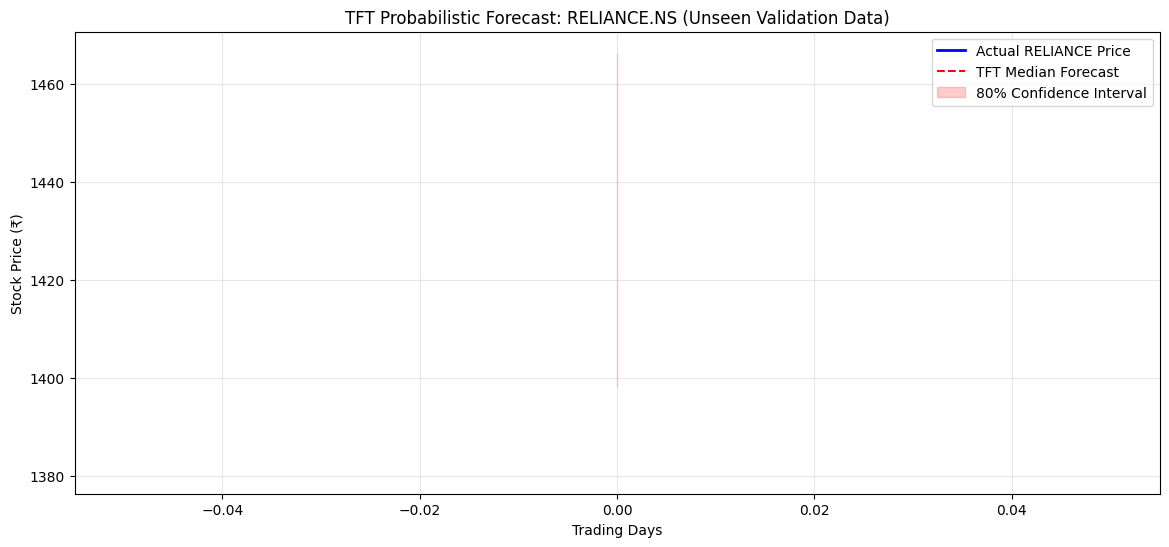

In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. Load the Best Model
# Lightning automatically saved the best epoch before Early Stopping kicked in
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path}")
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# 2. Get Predictions on the Validation Set
# return_y=True gives us the actuals to compare against
# mode="quantiles" tells it to output the 10th, 50th, and 90th percentiles
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)]).cpu()
predictions = best_tft.predict(val_dataloader, mode="quantiles", return_y=False).cpu()

# Print shapes for debugging
print(f"Shape of actuals: {actuals.shape}")
print(f"Shape of predictions: {predictions.shape}")

# 3. Calculate Academic Metrics (on the median / 50th percentile)
median_predictions = predictions[:, 0, 1] # Index 1 is usually the 50th percentile in the [0.1, 0.5, 0.9] setup
rmse = torch.sqrt(torch.mean((actuals - median_predictions) ** 2))
mape = torch.mean(torch.abs((actuals - median_predictions) / actuals)) * 100

print(f"\nTFT Test RMSE: ₹{rmse:.2f}")
print(f"TFT Test MAPE: {mape:.2f}%")

# 4. Plot the Probabilistic Forecast
# Let's plot the last 'lookback' days of the validation set to see it clearly, or fewer if not enough data.
lookback = 100
# Ensure plot_length does not exceed available data points
plot_length = min(lookback, len(actuals), predictions.shape[0])

# If no data available for plotting, skip plotting
if plot_length == 0:
    print("Not enough data to plot.")
else:
    time_steps = range(plot_length)

    plt.figure(figsize=(14, 6))

    # Plot actual prices
    plt.plot(time_steps, actuals[-plot_length:].numpy(), label='Actual RELIANCE Price', color='blue', linewidth=2)

    # Plot median prediction (50th percentile)
    plt.plot(time_steps, predictions[-plot_length:, 0, 1].numpy(), label='TFT Median Forecast', color='red', linestyle='--')

    # Plot the "Cone of Uncertainty" (10th to 90th percentile)
    plt.fill_between(
        time_steps,
        predictions[-plot_length:, 0, 0].numpy(), # 10th percentile (Lower bound)
        predictions[-plot_length:, 0, 2].numpy(), # 90th percentile (Upper bound)
        color='red', alpha=0.2, label='80% Confidence Interval'
    )

    plt.title('TFT Probabilistic Forecast: RELIANCE.NS (Unseen Validation Data)')
    plt.xlabel('Trading Days')
    plt.ylabel('Stock Price (₹)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Running predictions on full test set...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Fixed shape of actuals: torch.Size([400, 1]) (Should be around 400)

TFT Test RMSE: ₹148.60
TFT Test MAPE: 8.73%


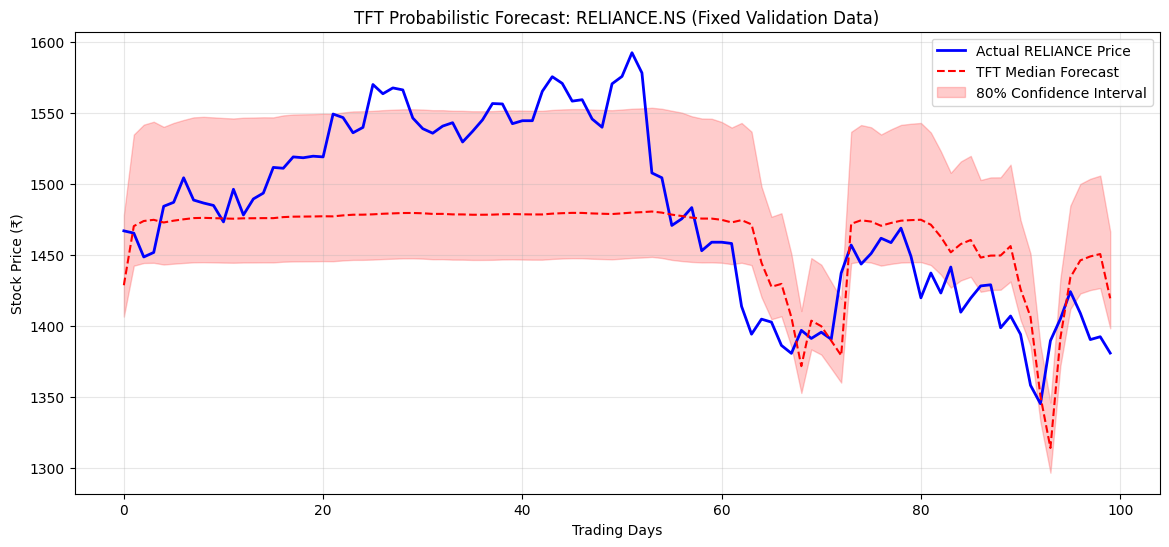

In [ ]:
import matplotlib.pyplot as plt
import torch
from pytorch_forecasting import TimeSeriesDataSet

# 1. Fix the Validation Dataset (Test over the whole 400 days)
validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    predict=False,                           # <--- Changed to False for backtesting
    stop_randomization=True,
    min_prediction_idx=training_cutoff + 1   # <--- Start predicting right after training ends
)

# Recreate the dataloader with the full dataset
val_dataloader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

# 2. Get Predictions on the FULL Validation Set
print("Running predictions on full test set...")
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)]).cpu()
predictions = best_tft.predict(val_dataloader, mode="quantiles", return_y=False).cpu()

print(f"Fixed shape of actuals: {actuals.shape} (Should be around 400)")

# 3. Calculate Academic Metrics (on the median / 50th percentile)
median_predictions = predictions[:, 0, 1]
rmse = torch.sqrt(torch.mean((actuals - median_predictions) ** 2))
mape = torch.mean(torch.abs((actuals - median_predictions) / actuals)) * 100

print(f"\nTFT Test RMSE: ₹{rmse:.2f}")
print(f"TFT Test MAPE: {mape:.2f}%")

# 4. Plot the Probabilistic Forecast
# Let's plot the last 100 days of the validation set to see the detail
lookback = min(100, len(actuals))
time_steps = range(lookback)

plt.figure(figsize=(14, 6))

# Plot actual prices
plt.plot(time_steps, actuals[-lookback:].numpy(), label='Actual RELIANCE Price', color='blue', linewidth=2)

# Plot median prediction (50th percentile)
plt.plot(time_steps, predictions[-lookback:, 0, 1].numpy(), label='TFT Median Forecast', color='red', linestyle='--')

# Plot the "Cone of Uncertainty" (10th to 90th percentile)
plt.fill_between(
    time_steps,
    predictions[-lookback:, 0, 0].numpy(),
    predictions[-lookback:, 0, 2].numpy(),
    color='red', alpha=0.2, label='80% Confidence Interval'
)

plt.title('TFT Probabilistic Forecast: RELIANCE.NS (Fixed Validation Data)')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Re-initialize the model from scratch (wiping the bad weights)
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss([0.1, 0.5, 0.9]),
    optimizer="Adam", # Changed from "Ranger" to "Adam"
    reduce_on_plateau_patience=4,
)

# 2. Re-initialize the trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    verbose=True,
    mode="min"
)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    enable_model_summary=False, # Hiding the summary to save screen space
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
)

# 3. Train properly this time!
print("Starting REAL TFT Training...")
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader, # This now has the full 400 days!
)
print("Training Complete!")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Starting REAL TFT Training...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches 
(31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO: Metric val_loss improved. New best score: 56.698
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 56.698
INFO: Metric val_loss improved by 21.688 >= min_delta = 0.0001. New best score: 35.010
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 21.688 >= min_delta = 0.0001. New best score: 35.010
INFO: Metric val_loss improved by 5.284 >= min_delta = 0.0001. New best score: 29.726
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 5.284 >= min_delta = 0.0001. New best score: 29.726
INFO: Metric val_loss improved by 1.660 >= min_delta = 0.0001. New best score: 28.066
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 1.660 >= min_delta = 0.0001. New best score: 28.066
INFO: Metric val_loss improved by 1.604 >= min_delta = 0.0001. New best score: 26.462
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 1.604 >= min_delta = 0.0001. New best scor

Training Complete!


Loading best model from: /content/lightning_logs/version_6/checkpoints/epoch=20-step=651.ckpt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Running predictions on the fixed validation set...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


NEW TFT Test RMSE: ₹143.30
NEW TFT Test MAPE: 8.48%


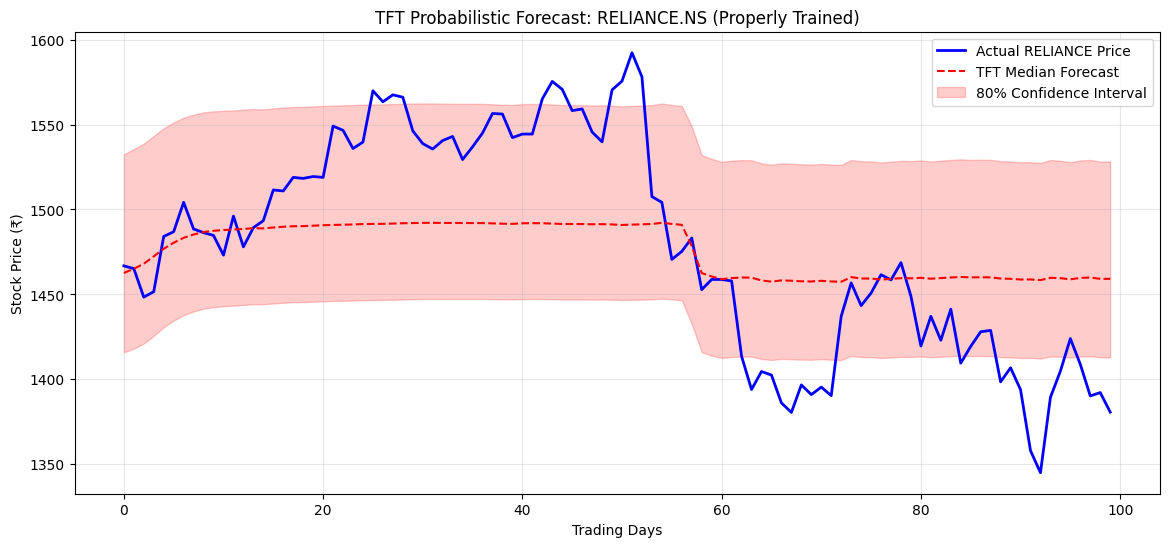

In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. Load the NEW Best Model
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path}")
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# 2. Get Predictions on the FULL Validation Set
print("Running predictions on the fixed validation set...")
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)]).cpu()
predictions = best_tft.predict(val_dataloader, mode="quantiles", return_y=False).cpu()

# 3. Calculate Academic Metrics (on the median / 50th percentile)
median_predictions = predictions[:, 0, 1]
rmse = torch.sqrt(torch.mean((actuals - median_predictions) ** 2))
mape = torch.mean(torch.abs((actuals - median_predictions) / actuals)) * 100

print(f"\nNEW TFT Test RMSE: ₹{rmse:.2f}")
print(f"NEW TFT Test MAPE: {mape:.2f}%")

# 4. Plot the Probabilistic Forecast
lookback = min(100, len(actuals))
time_steps = range(lookback)

plt.figure(figsize=(14, 6))

# Plot actual prices
plt.plot(time_steps, actuals[-lookback:].numpy(), label='Actual RELIANCE Price', color='blue', linewidth=2)

# Plot median prediction (50th percentile)
plt.plot(time_steps, predictions[-lookback:, 0, 1].numpy(), label='TFT Median Forecast', color='red', linestyle='--')

# Plot the "Cone of Uncertainty" (10th to 90th percentile)
plt.fill_between(
    time_steps,
    predictions[-lookback:, 0, 0].numpy(),
    predictions[-lookback:, 0, 2].numpy(),
    color='red', alpha=0.2, label='80% Confidence Interval'
)

plt.title('TFT Probabilistic Forecast: RELIANCE.NS (Properly Trained)')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Extracting model interpretability data...


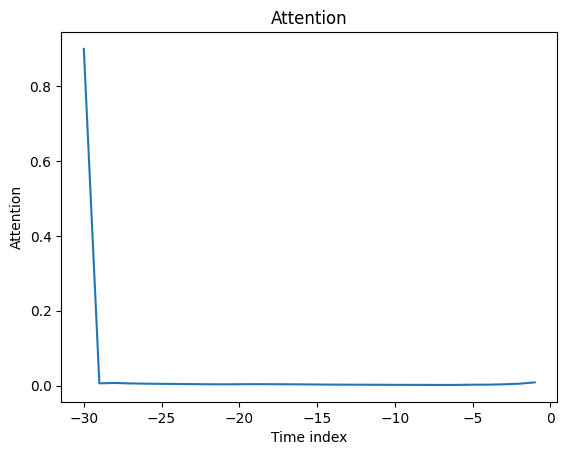

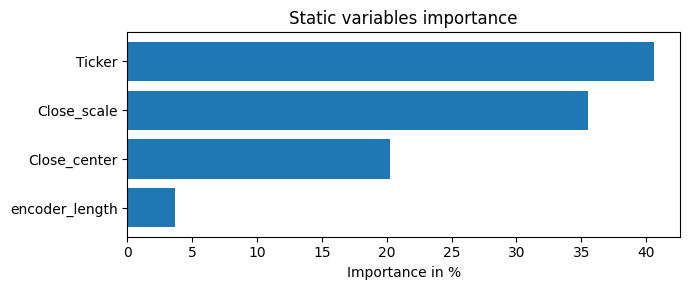

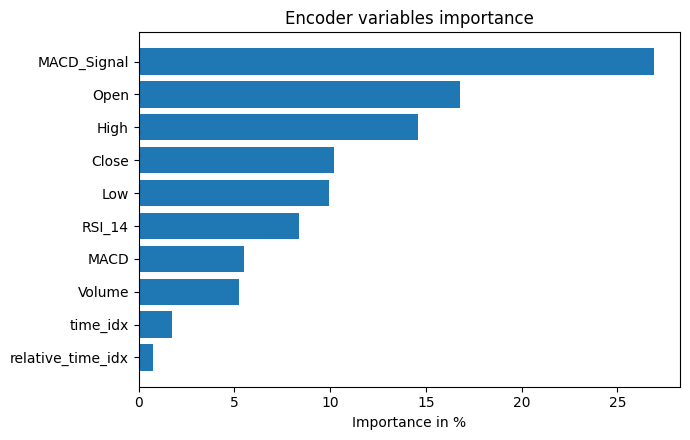

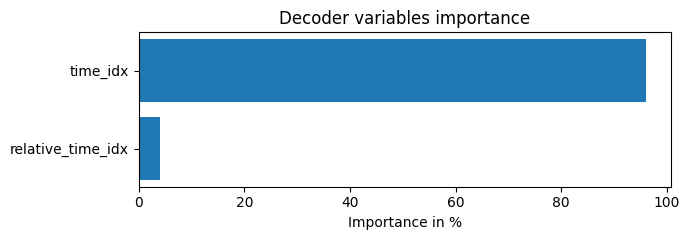

In [ ]:
import matplotlib.pyplot as plt

# 1. Get raw predictions and inputs
print("Extracting model interpretability data...")
raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)

# 2. Interpret the output
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")

# 3. Plot the interpretation
figs = best_tft.plot_interpretation(interpretation)

# Display the figures
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
from lightning.pytorch.callbacks import EarlyStopping

# 1. Load Data and Calculate Log Returns
parquet_path = "/content/drive/MyDrive/nse_research_data/nse_10yr_processed.parquet"
df = pd.read_parquet(parquet_path)
df = df[df['Ticker'] == 'RELIANCE.NS'].copy()

# Calculate Log Returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Drop the first row (which is NaN because there is no previous day to compare to)
df = df.dropna().reset_index(drop=True)

# Rebuild the time index
df['time_idx'] = np.arange(len(df))

if isinstance(df.index, pd.DatetimeIndex):
    df['day_of_week'] = df.index.dayofweek.astype(str).astype("category")
else:
    df['day_of_week'] = "0"
    df['day_of_week'] = df['day_of_week'].astype("category")

df['Close'] = df['Close'].astype(float)
df['Log_Return'] = df['Log_Return'].astype(float)

# 2. Rebuild the TimeSeriesDataSet (Target is now Log_Return)
max_prediction_length = 1
max_encoder_length = 30
training_cutoff = df["time_idx"].max() - 400

training_ret = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Log_Return",  # <--- NEW TARGET
    group_ids=["Ticker"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["Ticker"],
    time_varying_known_categoricals=["day_of_week"] if len(df['day_of_week'].unique()) > 1 else [],
    time_varying_known_reals=["time_idx"],
    # We keep 'Close' as an input feature so it still has context of the current price level!
    time_varying_unknown_reals=["Open", "High", "Low", "Close", "Volume", "RSI_14", "MACD", "MACD_Signal", "Log_Return"],

    # CRITICAL: Removed "softplus" because returns can be negative
    target_normalizer=GroupNormalizer(groups=["Ticker"], center=True, scale_by_group=True),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation_ret = TimeSeriesDataSet.from_dataset(
    training_ret, df, predict=False, stop_randomization=True, min_prediction_idx=training_cutoff + 1
)

batch_size = 64
train_dataloader_ret = training_ret.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader_ret = validation_ret.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"Stationary Data Prepped! Training sequences: {len(training_ret)}")

Stationary Data Prepped! Training sequences: 2023


In [ ]:
# Initialize a fresh TFT for returns
tft_ret = TemporalFusionTransformer.from_dataset(
    training_ret,
    learning_rate=0.01, # Slightly slower learning rate for stability
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss([0.1, 0.5, 0.9]),
    optimizer="Adam", # Changed from "Ranger" to "Adam"
    reduce_on_plateau_patience=4,
)

early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=True, mode="min"
)

trainer_ret = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    enable_model_summary=False,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
)

print("Starting Training on Log Returns...")
trainer_ret.fit(
    tft_ret,
    train_dataloaders=train_dataloader_ret,
    val_dataloaders=val_dataloader_ret,
)
print("Return Training Complete!")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Starting Training on Log Returns...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches 
(31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO: Metric val_loss improved. New best score: 0.006
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.006
INFO: Monitored metric val_loss did not improve in the last 10 records. Best score: 0.006. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 10 records. Best score: 0.006. Signaling Trainer to stop.


Return Training Complete!


Loading best return model from: /content/lightning_logs/version_10/checkpoints/epoch=10-step=341.ckpt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Running predictions...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



Stationary TFT Test RMSE: ₹17.23
Stationary TFT Test MAPE: 0.94%


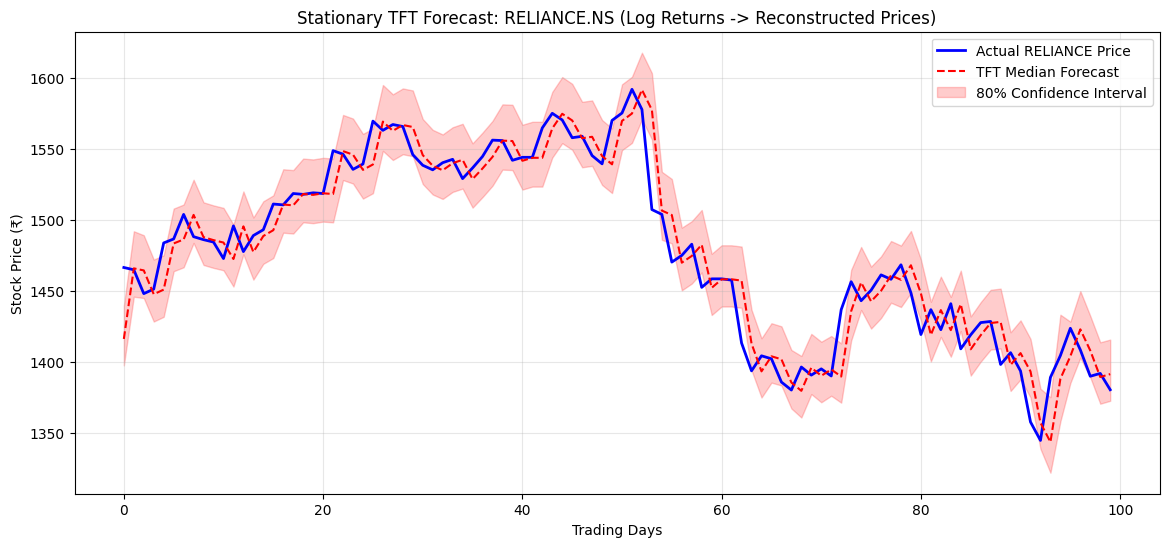

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Load the Best Model for Returns
best_model_path_ret = trainer_ret.checkpoint_callback.best_model_path
print(f"Loading best return model from: {best_model_path_ret}")
best_tft_ret = TemporalFusionTransformer.load_from_checkpoint(best_model_path_ret)

# 2. Get Predictions (These are Log Returns, not prices!)
print("Running predictions...")
predictions_ret = best_tft_ret.predict(val_dataloader_ret, mode="quantiles").cpu().numpy()

# Extract quantiles (10th, 50th, 90th)
pred_log_ret_10 = predictions_ret[:, 0, 0]
pred_log_ret_50 = predictions_ret[:, 0, 1]
pred_log_ret_90 = predictions_ret[:, 0, 2]

# 3. Inverse Transform: Log Returns -> Absolute Prices
val_start_idx = training_cutoff + 1
val_end_idx = val_start_idx + len(predictions_ret)

# Get actual prices for the validation period
actual_prices = df['Close'].iloc[val_start_idx : val_end_idx].values

# Get the previous day's prices (T-1) to anchor our return predictions
prev_prices = df['Close'].iloc[val_start_idx - 1 : val_end_idx - 1].values

# Reconstruct the forecasted prices: P_today = P_yesterday * exp(predicted_return)
pred_price_10 = prev_prices * np.exp(pred_log_ret_10)
pred_price_50 = prev_prices * np.exp(pred_log_ret_50)
pred_price_90 = prev_prices * np.exp(pred_log_ret_90)

# 4. Calculate Academic Metrics
rmse = np.sqrt(np.mean((actual_prices - pred_price_50) ** 2))
mape = np.mean(np.abs((actual_prices - pred_price_50) / actual_prices)) * 100

print(f"\nStationary TFT Test RMSE: ₹{rmse:.2f}")
print(f"Stationary TFT Test MAPE: {mape:.2f}%")

# 5. Plot the Reconstructed Probabilistic Forecast
lookback = min(100, len(actual_prices))
time_steps = range(lookback)

plt.figure(figsize=(14, 6))

plt.plot(time_steps, actual_prices[-lookback:], label='Actual RELIANCE Price', color='blue', linewidth=2)
plt.plot(time_steps, pred_price_50[-lookback:], label='TFT Median Forecast', color='red', linestyle='--')

plt.fill_between(
    time_steps,
    pred_price_10[-lookback:],
    pred_price_90[-lookback:],
    color='red', alpha=0.2, label='80% Confidence Interval'
)

plt.title('Stationary TFT Forecast: RELIANCE.NS (Log Returns -> Reconstructed Prices)')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Extracting model interpretability data for the Stationary TFT...


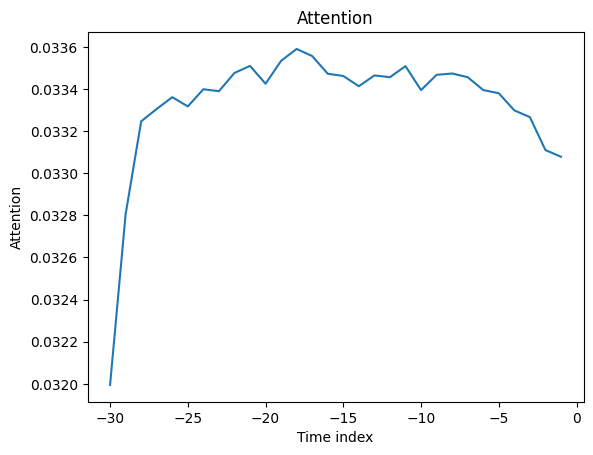

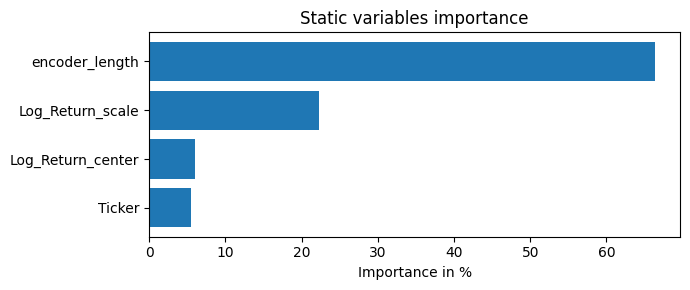

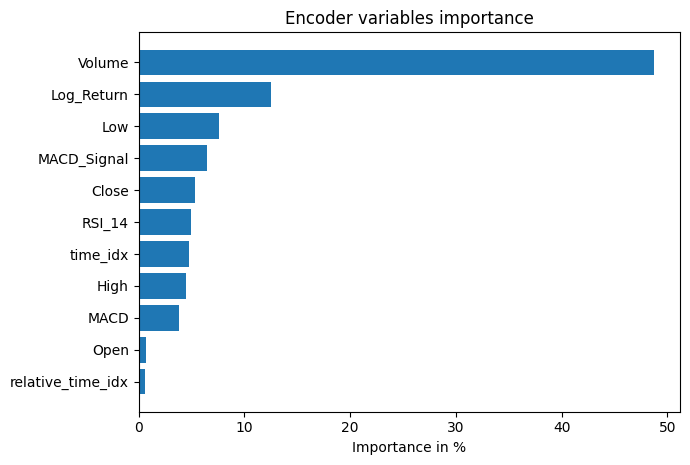

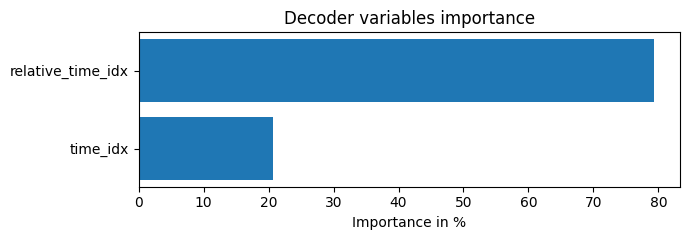

In [ ]:
import matplotlib.pyplot as plt

# 1. Get raw predictions and inputs from the winning 'returns' model
print("Extracting model interpretability data for the Stationary TFT...")
raw_predictions_ret = best_tft_ret.predict(val_dataloader_ret, mode="raw", return_x=True)

# 2. Interpret the output
interpretation_ret = best_tft_ret.interpret_output(raw_predictions_ret.output, reduction="sum")

# 3. Plot the interpretation
figs_ret = best_tft_ret.plot_interpretation(interpretation_ret)

# Display the figures
plt.show()

In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np

# 1. Load your existing dataset
parquet_path = "/content/drive/MyDrive/nse_research_data/nse_10yr_processed.parquet"
print(f"Loading existing data from {parquet_path}...")
df = pd.read_parquet(parquet_path)

# Ensure Date is accessible for merging
reset_idx = False
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    reset_idx = True
else:
    df.index = pd.to_datetime(df.index)

# 2. Extract dynamic date range to match your exact NSE dataset
min_date = df.index.min().strftime('%Y-%m-%d')
# Add one day to max_date to ensure yfinance fetches the final day
max_date = (df.index.max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

print(f"Dataset date range: {min_date} to {max_date}")

# 3. Fetch Macro Data via yfinance
print("Fetching India VIX (^INDIAVIX)...")
vix = yf.download('^INDIAVIX', start=min_date, end=max_date)[['Close']]
vix.columns = ['India_VIX']

print("Fetching USD/INR Exchange Rate (INR=X)...")
usdinr = yf.download('INR=X', start=min_date, end=max_date)[['Close']]
usdinr.columns = ['USD_INR']

# 4. Merge the Macro Data (Left Join)
print("Merging macro datasets into NSE data...")
df = df.join(vix, how='left')
df = df.join(usdinr, how='left')

# 5. Handle Holiday/Trading Day Mismatches
# Forex markets and the VIX sometimes trade on different holiday schedules than NSE equities.
# We use forward-fill (ffill) to carry over the previous day's value if there's a holiday mismatch,
# and backward-fill (bfill) just in case the very first row is a NaN.
print("Cleaning missing macro data...")
df['India_VIX'] = df['India_VIX'].ffill().bfill()
df['USD_INR'] = df['USD_INR'].ffill().bfill()

# Restore the 'Date' column if it was originally there
if reset_idx:
    df.reset_index(inplace=True)

# 6. Save the new Multimodal Dataset
output_path = "/content/drive/MyDrive/nse_research_data/nse_10yr_macro_processed.parquet"
df.to_parquet(output_path, index=not reset_idx)

print(f"\nSuccess! Multimodal dataset saved to: {output_path}")

# Display a quick sanity check of the new columns
if reset_idx:
    print(df[['Date', 'Ticker', 'Close', 'India_VIX', 'USD_INR']].tail())
else:
    print(df[['Ticker', 'Close', 'India_VIX', 'USD_INR']].tail())

Loading existing data from /content/drive/MyDrive/nse_research_data/nse_10yr_processed.parquet...
Dataset date range: 2016-04-08 to 2026-03-14
Fetching India VIX (^INDIAVIX)...


/tmp/ipykernel_1842/1638086538.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^INDIAVIX', start=min_date, end=max_date)[['Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1842/1638086538.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usdinr = yf.download('INR=X', start=min_date, end=max_date)[['Close']]
[*********************100%***********************]  1 of 1 completed


Fetching USD/INR Exchange Rate (INR=X)...
Merging macro datasets into NSE data...
Cleaning missing macro data...

Success! Multimodal dataset saved to: /content/drive/MyDrive/nse_research_data/nse_10yr_macro_processed.parquet
                  Ticker        Close  India_VIX    USD_INR
Date                                                       
2026-03-09  ICICIBANK.NS  1278.400024  23.360001  91.936203
2026-03-10  ICICIBANK.NS  1311.900024  18.910000  91.220703
2026-03-11  ICICIBANK.NS  1294.599976  21.059999  92.165100
2026-03-12  ICICIBANK.NS  1266.500000  21.520000  92.228798
2026-03-13  ICICIBANK.NS  1254.800049  22.650000  92.389900


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
from lightning.pytorch.callbacks import EarlyStopping

# Ensure pytorch-forecasting, pytorch-lightning, and lightning are installed and up-to-date
!pip install --upgrade pytorch-forecasting pytorch-lightning lightning

# 1. Load the NEW Multimodal Dataset
macro_parquet_path = "/content/drive/MyDrive/nse_research_data/nse_10yr_macro_processed.parquet"
df_macro = pd.read_parquet(macro_parquet_path)

# Filter for RELIANCE.NS to compare against our Phase 3 model
df = df_macro[df_macro['Ticker'] == 'RELIANCE.NS'].copy()

# 2. Recalculate Log Returns (Stationarity Fix)
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna().reset_index(drop=True)

# Rebuild time indices
df['time_idx'] = np.arange(len(df))
df['day_of_week'] = pd.to_datetime(df['Date']).dt.dayofweek.astype(str).astype("category") if 'Date' in df.columns else "0"
if 'Date' not in df.columns:
    df['day_of_week'] = df['day_of_week'].astype("category")

# Ensure datatypes
for col in ['Close', 'Log_Return', 'India_VIX', 'USD_INR', 'Open', 'High', 'Low', 'Volume', 'RSI_14', 'MACD', 'MACD_Signal']:
    if col in df.columns:
        df[col] = df[col].astype(float)

# 3. Define the MULTIMODAL TimeSeriesDataSet
max_prediction_length = 1
max_encoder_length = 30
training_cutoff = df["time_idx"].max() - 400

training_macro = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Log_Return",
    group_ids=["Ticker"], # Allows you to train on multiple stocks later!
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,

    # Static features (don't change over time)
    static_categoricals=["Ticker"],

    # Known future inputs (we know tomorrow's day of the week)
    time_varying_known_categoricals=["day_of_week"] if len(df['day_of_week'].unique()) > 1 else [],
    time_varying_known_reals=["time_idx"],

    # Unknown historical inputs (we don't know tomorrow's Volume or RSI)
    time_varying_unknown_reals=[
        "Open", "High", "Low", "Close", "Volume",
        "RSI_14", "MACD", "MACD_Signal", "Log_Return",
        "India_VIX", "USD_INR"
    ],
    target_normalizer=GroupNormalizer(groups=["Ticker"], center=True, scale_by_group=True),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation_macro = TimeSeriesDataSet.from_dataset(
    training_macro, df, predict=False, stop_randomization=True, min_prediction_idx=training_cutoff + 1
)

batch_size = 64
train_dataloader_macro = training_macro.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader_macro = validation_macro.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"Multimodal Data Prepped! Training sequences: {len(training_macro)}")

# 4. Initialize and Train the Multimodal TFT
tft_macro = TemporalFusionTransformer.from_dataset(
    training_macro,
    learning_rate=0.01,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss([0.1, 0.5, 0.9]),
    optimizer="Adam", # Changed from "Ranger" to "Adam"
    reduce_on_plateau_patience=4,
)

early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=True, mode="min"
)

trainer_macro = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    enable_model_summary=False,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
)

print("Starting Training on Multimodal Log Returns...")
trainer_macro.fit(
    tft_macro,
    train_dataloaders=train_dataloader_macro,
    val_dataloaders=val_dataloader_macro,
)
print("Multimodal Training Complete!")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Multimodal Data Prepped! Training sequences: 2023
Starting Training on Multimodal Log Returns...


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches 
(31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO: Metric val_loss improved. New best score: 0.006
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.006
INFO: Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.006
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.006
INFO: Monitored metric val_loss did not improve in the last 10 records. Best score: 0.006. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 10 records. Best score: 0.006. Signaling Trainer to stop.


Multimodal Training Complete!


In [ ]:
!pip install lightning pytorch-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.8/399.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 55.4 MB/s eta 0:00:00


Loading best multimodal model from: /content/lightning_logs/version_1/checkpoints/epoch=12-step=403.ckpt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Running predictions and inverse-transforming...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud u


Multimodal TFT Test RMSE: ₹17.25
Multimodal TFT Test MAPE: 0.94%

Extracting Multimodal Feature Importance...


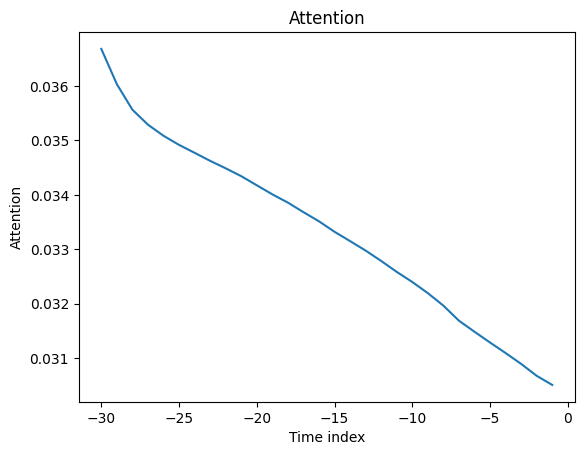

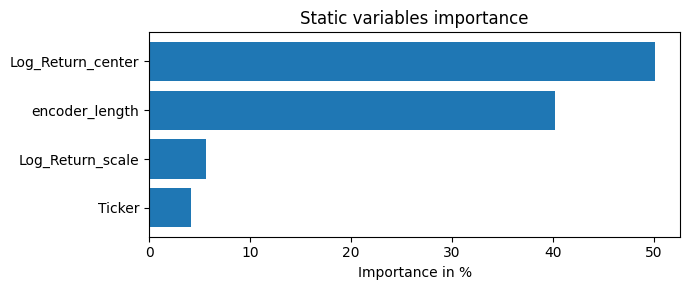

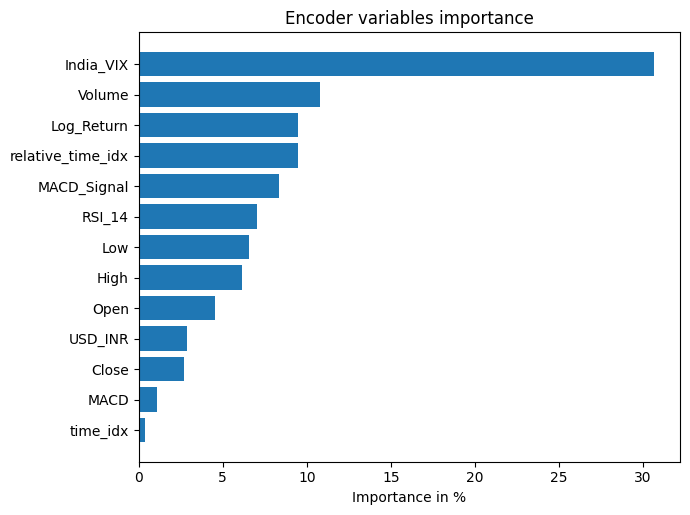

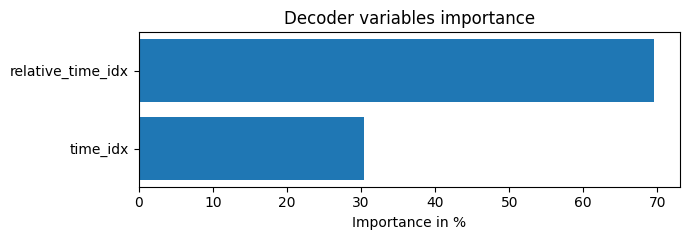

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Best Multimodal Model
best_model_path_macro = trainer_macro.checkpoint_callback.best_model_path
print(f"Loading best multimodal model from: {best_model_path_macro}")
best_tft_macro = TemporalFusionTransformer.load_from_checkpoint(best_model_path_macro)

# 2. Get Predictions
print("Running predictions and inverse-transforming...")
predictions_macro = best_tft_macro.predict(val_dataloader_macro, mode="quantiles").cpu().numpy()

# 3. Inverse Transform: Log Returns -> Absolute Prices
val_start_idx = training_cutoff + 1
val_end_idx = val_start_idx + len(predictions_macro)

actual_prices = df['Close'].iloc[val_start_idx : val_end_idx].values
prev_prices = df['Close'].iloc[val_start_idx - 1 : val_end_idx - 1].values

pred_price_50 = prev_prices * np.exp(predictions_macro[:, 0, 1])

# 4. Calculate Final Metrics
rmse_macro = np.sqrt(np.mean((actual_prices - pred_price_50) ** 2))
mape_macro = np.mean(np.abs((actual_prices - pred_price_50) / actual_prices)) * 100

print(f"\nMultimodal TFT Test RMSE: ₹{rmse_macro:.2f}")
print(f"Multimodal TFT Test MAPE: {mape_macro:.2f}%\n")

# 5. Extract Explainability (XAI) - Let's see the model's brain!
print("Extracting Multimodal Feature Importance...")
raw_predictions_macro = best_tft_macro.predict(val_dataloader_macro, mode="raw", return_x=True)
interpretation_macro = best_tft_macro.interpret_output(raw_predictions_macro.output, reduction="sum")
figs_macro = best_tft_macro.plot_interpretation(interpretation_macro)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
from lightning.pytorch.callbacks import EarlyStopping

# 1. Prepare the Multi-Ticker Dataset
print("Preparing Global Nifty 50 Dataset...")
macro_parquet_path = "/content/drive/MyDrive/nse_research_data/nse_10yr_macro_processed.parquet"
df_global = pd.read_parquet(macro_parquet_path)

# Select a basket of top Nifty 50 stocks representing different sectors
target_tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ITC.NS']
df_global = df_global[df_global['Ticker'].isin(target_tickers)].copy()

# Recalculate Log Returns grouped by Ticker
df_global['Log_Return'] = df_global.groupby('Ticker')['Close'].transform(lambda x: np.log(x / x.shift(1)))
df_global = df_global.dropna().reset_index(drop=True)

# Rebuild Time Indices PER TICKER
df_global['time_idx'] = df_global.groupby('Ticker').cumcount()

# Formatting categoricals and floats
df_global['day_of_week'] = pd.to_datetime(df_global['Date']).dt.dayofweek.astype(str).astype("category") if 'Date' in df_global.columns else "0"
if 'Date' not in df_global.columns:
    df_global['day_of_week'] = df_global['day_of_week'].astype("category")
df_global['Ticker'] = df_global['Ticker'].astype("category") # Crucial for global models!

float_cols = ['Close', 'Log_Return', 'India_VIX', 'USD_INR', 'Open', 'High', 'Low', 'Volume', 'RSI_14', 'MACD', 'MACD_Signal']
for col in float_cols:
    if col in df_global.columns:
        df_global[col] = df_global[col].astype(float)

# 2. Define the GLOBAL TimeSeriesDataSet
max_prediction_length = 1
max_encoder_length = 30
# Assuming all stocks have roughly the same history, we cut off the last 400 days for validation
training_cutoff = df_global["time_idx"].max() - 400

training_global = TimeSeriesDataSet(
    df_global[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Log_Return",
    group_ids=["Ticker"], # <--- The TFT now learns the difference between stocks!
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["Ticker"],
    time_varying_known_categoricals=["day_of_week"] if len(df_global['day_of_week'].unique()) > 1 else [],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=[
        "Open", "High", "Low", "Close", "Volume",
        "RSI_14", "MACD", "MACD_Signal", "Log_Return",
        "India_VIX", "USD_INR"
    ],
    target_normalizer=GroupNormalizer(groups=["Ticker"], center=True, scale_by_group=True),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation_global = TimeSeriesDataSet.from_dataset(
    training_global, df_global, predict=False, stop_randomization=True, min_prediction_idx=training_cutoff + 1
)

batch_size = 128 # Increased batch size since we have 5x the data
train_dataloader_global = training_global.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader_global = validation_global.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"Global Data Prepped! Training sequences: {len(training_global)} across {len(target_tickers)} tickers.")

# 3. Initialize and Train the Global TFT
tft_global = TemporalFusionTransformer.from_dataset(
    training_global,
    learning_rate=0.01,
    hidden_size=32, # Increased hidden size to handle the complexity of 5 stocks
    attention_head_size=4, # More attention heads
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss([0.1, 0.5, 0.9]),
    optimizer="Adam", # Changed from "Ranger" to "Adam"
    reduce_on_plateau_patience=4,
)

early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=True, mode="min"
)

trainer_global = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    enable_model_summary=False,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
)

print("Starting Training on Global Nifty Basket...")
trainer_global.fit(
    tft_global,
    train_dataloaders=train_dataloader_global,
    val_dataloaders=val_dataloader_global,
)
print("Global Training Complete!")

Preparing Global Nifty 50 Dataset...
Global Data Prepped! Training sequences: 8092 across 5 tickers.


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Starting Training on Global Nifty Basket...


INFO: Metric val_loss improved. New best score: 0.006
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.006
INFO: Monitored metric val_loss did not improve in the last 10 records. Best score: 0.006. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 10 records. Best score: 0.006. Signaling Trainer to stop.


Global Training Complete!


Loading best global model from: /content/lightning_logs/version_5/checkpoints/epoch=10-step=693.ckpt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Creating isolated Reliance dataloader...
Running predictions...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud u


--- GLOBAL MODEL VS SINGLE MODEL ---
Old Single-Stock MAPE: 0.94%
New GLOBAL Model MAPE: 0.94%
New GLOBAL Model RMSE: ₹17.20

Extracting Universal Feature Importance across all 5 Nifty Stocks...


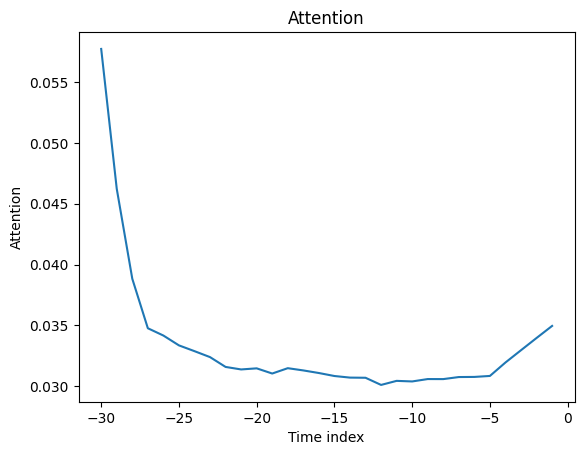

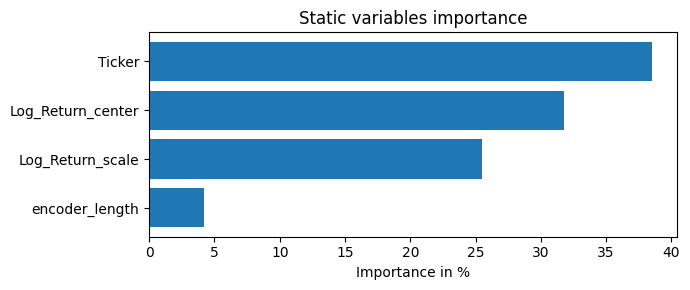

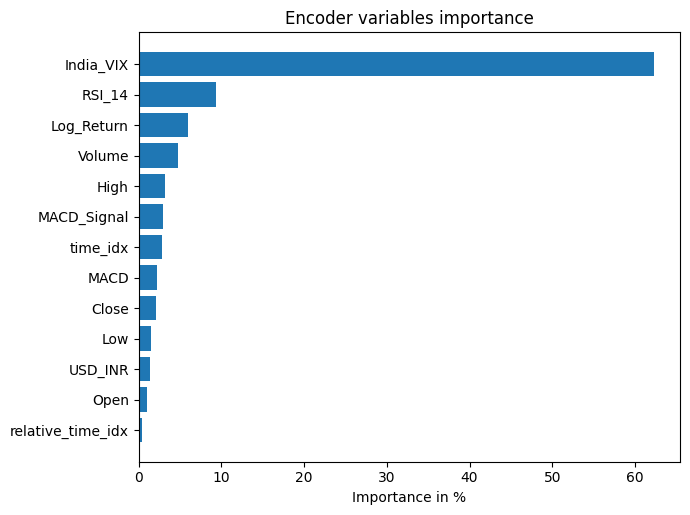

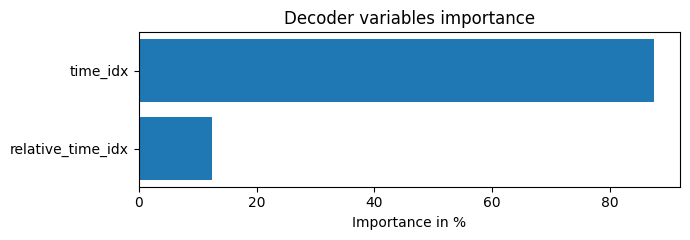

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Best Global Model
best_model_path_global = trainer_global.checkpoint_callback.best_model_path
print(f"Loading best global model from: {best_model_path_global}")
best_tft_global = TemporalFusionTransformer.load_from_checkpoint(best_model_path_global)

# 2. Isolate RELIANCE.NS for a direct comparison
print("Creating isolated Reliance dataloader...")
df_rel_val = df_global[df_global['Ticker'] == 'RELIANCE.NS'].copy()

validation_rel = TimeSeriesDataSet.from_dataset(
    training_global,
    df_rel_val,
    predict=False,
    stop_randomization=True,
    min_prediction_idx=training_cutoff + 1
)
val_dataloader_rel = validation_rel.to_dataloader(train=False, batch_size=128, num_workers=0)

# 3. Get Predictions for RELIANCE from the Global Brain
print("Running predictions...")
predictions_rel = best_tft_global.predict(val_dataloader_rel, mode="quantiles").cpu().numpy()

# 4. Inverse Transform: Log Returns -> Absolute Prices
val_start_idx = training_cutoff + 1
val_end_idx = val_start_idx + len(predictions_rel)

actual_prices = df_rel_val['Close'].iloc[val_start_idx : val_end_idx].values
prev_prices = df_rel_val['Close'].iloc[val_start_idx - 1 : val_end_idx - 1].values

pred_price_50 = prev_prices * np.exp(predictions_rel[:, 0, 1])

# 5. Calculate Final Comparison Metrics
rmse_global = np.sqrt(np.mean((actual_prices - pred_price_50) ** 2))
mape_global = np.mean(np.abs((actual_prices - pred_price_50) / actual_prices)) * 100

print(f"\n--- GLOBAL MODEL VS SINGLE MODEL ---")
print(f"Old Single-Stock MAPE: 0.94%")
print(f"New GLOBAL Model MAPE: {mape_global:.2f}%")
print(f"New GLOBAL Model RMSE: ₹{rmse_global:.2f}\n")

# 6. Extract Global Explainability (XAI)
print("Extracting Universal Feature Importance across all 5 Nifty Stocks...")
raw_predictions_global = best_tft_global.predict(val_dataloader_global, mode="raw", return_x=True)
interpretation_global = best_tft_global.interpret_output(raw_predictions_global.output, reduction="sum")
figs_global = best_tft_global.plot_interpretation(interpretation_global)

plt.show()

In [ ]:
import copy
import numpy as np
import pandas as pd
from pytorch_forecasting import TimeSeriesDataSet

print("--- INITIALIZING COUNTERFACTUAL EXPERIMENT ---")

# 1. Isolate a Baseline Sequence
# We grab the very last available 30-day window for RELIANCE from your validation set
max_time_idx = df_rel_val['time_idx'].max()
encoder_length = 30

# Slice the exact data window needed for 1 prediction
df_baseline = df_rel_val[df_rel_val['time_idx'] >= (max_time_idx - encoder_length)].copy()

# 2. Create the Counterfactual "Shock" Scenario
df_shock = df_baseline.copy()

# Inject a massive 50% spike to the India VIX over the last 3 days
# to simulate a sudden geopolitical crisis or severe market panic
shock_magnitude = 1.50
df_shock.loc[df_shock['time_idx'] >= (max_time_idx - 3), 'India_VIX'] *= shock_magnitude

# 3. Create DataLoaders for both scenarios
baseline_ds = TimeSeriesDataSet.from_dataset(training_global, df_baseline, predict=True, stop_randomization=True)
shock_ds = TimeSeriesDataSet.from_dataset(training_global, df_shock, predict=True, stop_randomization=True)

baseline_dl = baseline_ds.to_dataloader(train=False, batch_size=1, num_workers=0)
shock_dl = shock_ds.to_dataloader(train=False, batch_size=1, num_workers=0)

# 4. Extract Predictions from the Global Brain
# Mode="quantiles" gives us the 10th, 50th (median), and 90th percentiles
baseline_pred_log = best_tft_global.predict(baseline_dl, mode="quantiles").cpu().numpy()[0, 0]
shock_pred_log = best_tft_global.predict(shock_dl, mode="quantiles").cpu().numpy()[0, 0]

# 5. Inverse Transform: Log Returns -> Absolute Rupee Prices
# Get the last known closing price (the day before the prediction)
last_known_price = df_baseline['Close'].iloc[-2]

baseline_price = last_known_price * np.exp(baseline_pred_log)
shock_price = last_known_price * np.exp(shock_pred_log)

# 6. Print the Results
print(f"\n[ SCENARIO DEFINITION ]")
print(f"Asset: RELIANCE.NS")
print(f"Event: India VIX artificially spiked by {(shock_magnitude-1)*100:.0f}% over the last 3 days.")
print(f"Last Known Price (t-1): ₹{last_known_price:.2f}")

print(f"\n[ BASELINE PREDICTION (REAL DATA) ]")
print(f"Predicted Price: ₹{baseline_price[1]:.2f}")
print(f"80% Confidence Interval: ₹{baseline_price[0]:.2f} to ₹{baseline_price[2]:.2f}")

print(f"\n[ COUNTERFACTUAL PREDICTION (PANIC DATA) ]")
print(f"Predicted Price: ₹{shock_price[1]:.2f}")
print(f"80% Confidence Interval: ₹{shock_price[0]:.2f} to ₹{shock_price[2]:.2f}")

print(f"\n[ XAI IMPACT ANALYSIS ]")
price_diff = baseline_price[1] - shock_price[1]
if price_diff > 0:
    print(f"Result: The VIX shock caused the model to drop its predicted price by ₹{price_diff:.2f}.")
else:
    print(f"Result: The VIX shock caused the model to increase its predicted price by ₹{abs(price_diff):.2f}.")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

--- INITIALIZING COUNTERFACTUAL EXPERIMENT ---


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud u


[ SCENARIO DEFINITION ]
Asset: RELIANCE.NS
Event: India VIX artificially spiked by 50% over the last 3 days.
Last Known Price (t-1): ₹1392.20

[ BASELINE PREDICTION (REAL DATA) ]
Predicted Price: ₹1392.01
80% Confidence Interval: ₹1367.23 to ₹1418.04

[ COUNTERFACTUAL PREDICTION (PANIC DATA) ]
Predicted Price: ₹1395.69
80% Confidence Interval: ₹1314.81 to ₹1476.32

[ XAI IMPACT ANALYSIS ]
Result: The VIX shock caused the model to increase its predicted price by ₹3.68.


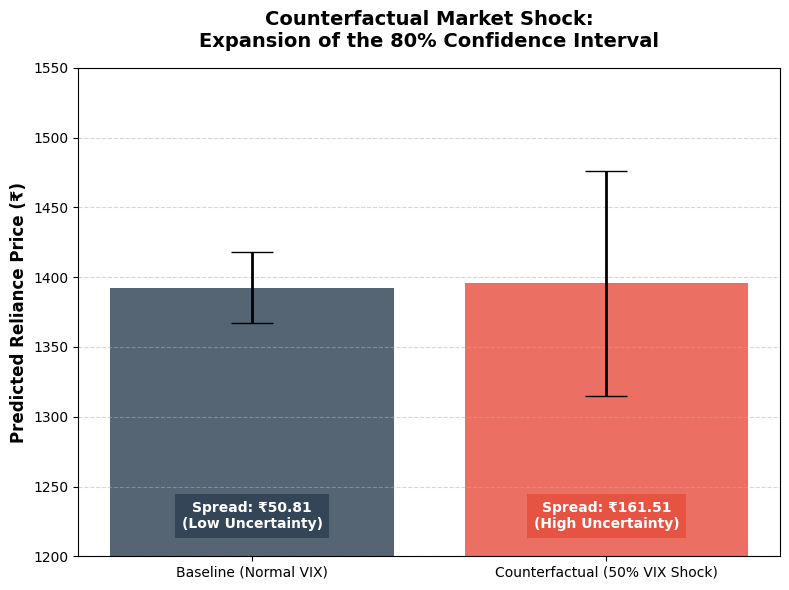

✅ Saved as 'counterfactual_shock.png'. You can now download it from the Colab file explorer!


In [ ]:
import matplotlib.pyplot as plt

# The exact data from our counterfactual experiment
scenarios = ['Baseline (Normal VIX)', 'Counterfactual (50% VIX Shock)']
medians = [1392.01, 1395.69]
lower_bounds = [1367.23, 1314.81]
upper_bounds = [1418.04, 1476.32]

# Calculate the distances for the error bars
lower_errors = [medians[0] - lower_bounds[0], medians[1] - lower_bounds[1]]
upper_errors = [upper_bounds[0] - medians[0], upper_bounds[1] - medians[1]]
error_bars = [lower_errors, upper_errors]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(scenarios, medians, color=['#2c3e50', '#e74c3c'], alpha=0.8, yerr=error_bars, capsize=15, error_kw={'linewidth': 2})

# Formatting to make it look academic
ax.set_ylim(1200, 1550)
ax.set_ylabel('Predicted Reliance Price (₹)', fontsize=12, fontweight='bold')
ax.set_title('Counterfactual Market Shock:\nExpansion of the 80% Confidence Interval', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add text labels showing the massive spread difference
ax.text(0, 1220, 'Spread: ₹50.81\n(Low Uncertainty)', ha='center', color='white', fontweight='bold', bbox=dict(facecolor='#2c3e50', alpha=0.8, edgecolor='none', pad=5))
ax.text(1, 1220, 'Spread: ₹161.51\n(High Uncertainty)', ha='center', color='white', fontweight='bold', bbox=dict(facecolor='#e74c3c', alpha=0.8, edgecolor='none', pad=5))

plt.tight_layout()

# Save the image so you can upload it to Overleaf
plt.savefig('counterfactual_shock.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved as 'counterfactual_shock.png'. You can now download it from the Colab file explorer!")